<a href="https://colab.research.google.com/github/ajs-sw/2026_tues_bigdatacomputing_class/blob/main/20230579_%EC%95%88%EC%A0%95%EC%88%98_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 기말고사 과제 제출

In [7]:
!pip install streamlit -q
!pip install pyngrok -q
!pip install joblib -q
!pip install streamlit pyngrok joblib -q

In [8]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

print("📊 WHO 기대수명 데이터셋 로드 및 전처리 중...")
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)

rename_dict = {}
for real_col in df.columns:
    clean_col = real_col.strip().lower() if hasattr(real_col, 'strip') else str(real_col)

    if 'expectancy' in clean_col:
        rename_dict[real_col] = 'Life expectancy'
    elif 'mortality' in clean_col and 'adult' in clean_col:
        rename_dict[real_col] = 'Adult Mortality'
    elif 'bmi' in clean_col:
        rename_dict[real_col] = 'BMI'
    elif 'gdp' in clean_col:
        rename_dict[real_col] = 'GDP'

df = df.rename(columns=rename_dict)

df.columns = df.columns.str.replace('.', ' ', regex=False).str.replace('_', ' ', regex=False).str.strip()

features = ['Adult Mortality', 'BMI', 'GDP']
target = 'Life expectancy'
df = df.dropna(subset=[target] + features)

X = df[features]
y = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train_full.sample(n=50, random_state=42)
y_train = y_train_full.loc[X_train.index]

print(f"📈 데이터 변환 및 준비 완료: 학습용 {X_train.shape[0]}개, 테스트용 {X_test.shape[0]}개")
print(f"📌 실제 사용된 변수 확인: {list(X_train.columns)}")

pipelines = {
    "Linear": Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())]),
    "Poly": Pipeline([("scaler", StandardScaler()), ("poly", PolynomialFeatures(degree=3)), ("reg", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("poly", PolynomialFeatures(degree=3)), ("reg", Ridge(alpha=1.0, random_state=42))])
}

evaluation_summary = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    if "poly" in pipeline.named_steps:
        complexity = pipeline.named_steps["poly"].transform(X_train.iloc[[0]]).shape[1]
    else:
        complexity = X_train.shape[1]

    evaluation_summary[name] = {
        "train_r2": float(r2_score(y_train, y_train_pred)),
        "test_r2": float(r2_score(y_test, y_test_pred)),
        "train_mse": float(mean_squared_error(y_train, y_train_pred)),
        "test_mse": float(mean_squared_error(y_test, y_test_pred)),
        "complexity": int(complexity)
    }

# 대시보드 배포용 데이터 패키징 저장
payload = {
    "models": pipelines,
    "cv_results": evaluation_summary,
    "features": features,
    "feature_bounds": {feat: {"min": float(df[feat].min()), "max": float(df[feat].max()), "mean": float(df[feat].mean())} for feat in features}
}

joblib.dump(payload, "life_expectancy_models.pkl")
print("\n✅ 'life_expectancy_models.pkl' 파일이 드디어 완벽하게 생성되었습니다!")

📊 WHO 기대수명 데이터셋 로드 및 전처리 중...
📈 데이터 변환 및 준비 완료: 학습용 50개, 테스트용 493개
📌 실제 사용된 변수 확인: ['Adult Mortality', 'BMI', 'GDP']

✅ 'life_expectancy_models.pkl' 파일이 드디어 완벽하게 생성되었습니다!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


In [9]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# 웹 브라우저 레이아웃 설정
st.set_page_config(page_title="기대수명 예측 파이프라인", layout="wide")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 대시보드 타이틀
st.title("📊 기대수명 다중 특성 회귀 모델 분석 및 웹 대시보드")
st.write("학습 및 검증이 완료된 Linear, Poly, Ridge 모델을 기반으로 다중 성능 지표를 분석하고 실시간 예측을 수행합니다.")
st.markdown("---")

# 1. 파일에서 저장된 모델 및 메타데이터 로드
@st.cache_resource
def load_classifier_data():
    try:
        return joblib.load("life_expectancy_models.pkl")
    except FileNotFoundError:
        st.error("⚠️ 'life_expectancy_models.pkl' 파일이 존재하지 않습니다. 먼저 모델 학습 코드를 실행해 주세요!")
        return None

payload = load_classifier_data()

if payload is not None:
    models = payload["models"]
    cv_results = payload["cv_results"]
    features = payload["features"]
    bounds = payload["feature_bounds"]

    # 2. 대시보드 영역: 모델별 성능 평가 통합 비교 (조건 3 만족)
    st.subheader("📋 독립된 검증 데이터(Test Data) 기반 종합 성능 비교")

    summary_data = []
    for model_name, info in cv_results.items():
        summary_data.append({
            "모델명": model_name,
            "Complexity (특성수)": info["complexity"],
            "Train R² (결정계수)": f"{info['train_r2']:.4f}",
            "Test R² (결정계수)": f"{info['test_r2']:.4f}",
            "Train MSE": f"{info['train_mse']:.2f}",
            "Test MSE": f"{info['test_mse']:.2f}"
        })

    df_summary = pd.DataFrame(summary_data)
    st.dataframe(df_summary, use_container_width=True, hide_index=True)

    # 2-2. 시각화 지표 구현 (Matplotlib 막대그래프)

    st.markdown("### 📉 모델별 Test R² 점수 비교 시각화")
    fig, ax = plt.subplots(figsize=(10, 4))

    model_names = [res["모델명"] for res in summary_data]
    test_r2_scores = [cv_results[name]["test_r2"] for name in model_names]

    # 시각적인 구분을 위해 바 차트 생성
    bars = ax.bar(model_names, test_r2_scores, color=['#4EA8DE', '#EA526F', '#25A18E'], edgecolor='black', width=0.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_ylabel("Test R² Score", fontsize=11)
    ax.set_title("Test R² Score Comparison (Higher is Better)", fontsize=12, fontweight='bold')

    # 막대 위에 값 표시
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -15),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    st.pyplot(fig)
    st.markdown("---")

    # 3. 사용자 입력 UI 및 실시간 예측

    # 3-1. 사이드바 구성
    st.sidebar.header("📋 새로운 데이터 입력")

    user_inputs = {}
    for feat in features:
        min_v = float(bounds[feat]["min"])
        max_v = float(bounds[feat]["max"])
        mean_v = float(bounds[feat]["mean"])

        step_v = 1.0 if feat != 'GDP' else 50.0
        user_inputs[feat] = st.sidebar.slider(f"{feat} 입력", min_value=min_v, max_value=max_v, value=mean_v, step=step_v)

    model_choice = st.selectbox("🔮 분석에 사용할 회귀 모델을 선택하세요", list(models.keys()))

    newdata = pd.DataFrame([user_inputs])

    # 3-2. 실시간 동적 예측 결과 출력
    if st.sidebar.button("🔮 기대수명 예측하기"):
        st.subheader(f"🗣️ 실시간 예측 판정 결과")

        selected_model = models[model_choice]
        pred_value = selected_model.predict(newdata)[0]

        col1, col2 = st.columns([1, 2])
        with col1:
            st.info(f"### 📌 선택된 알고리즘: {model_choice}")
            st.metric(label="📊 예측 기대수명 결과", value=f"{pred_value:.2f} 세")

        with col2:
            st.markdown("**💡 결과 분석 및 팁**")
            if model_choice == "Poly":
                st.warning("⚠️ **Poly(규제 없음)** 모델은 50개의 적은 데이터로 인해 극심한 과대적합(Overfitting) 상태일 수 있습니다. 예측값의 신뢰도가 떨어질 수 있으니 Ridge 결과와 비교해 보세요!")
            elif model_choice == "Ridge":
                st.success("✨ **Ridge(규제 포함)** 모델은 다항 변환 후 L2 규제를 적용하여 Poly 모델보다 훨씬 안정적이고 일반화된 기대수명을 제공합니다.")
            else:
                st.info("ℹ️ **Linear(기본 선형)** 모델은 차원 변환 없이 직선 형태로 경향성만 파악하므로 직관적이지만 복잡한 데이터 곡선을 반영하진 못합니다.")
    else:
        st.warning("👈 왼쪽 사이드바에서 수치를 조절해 준 다음 **[🔮 기대수명 예측하기]** 버튼을 눌러주세요!")

Overwriting app.py


In [12]:
import getpass
from pyngrok import ngrok
import os
import time


ngrok.kill()

NGROK_AUTH_TOKEN = getpass.getpass("Enter your ngrok authtoken: ")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

time.sleep(3)

# ngrok 터널 열기
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"🎉 성공적으로 배포되었습니다! 아래 퍼블릭 주소를 클릭하세요:\n{public_url}")
print("=" * 60)

Enter your ngrok authtoken: ··········
🎉 성공적으로 배포되었습니다! 아래 퍼블릭 주소를 클릭하세요:
NgrokTunnel: "https://sandal-amplify-flaxseed.ngrok-free.dev" -> "http://localhost:8501"


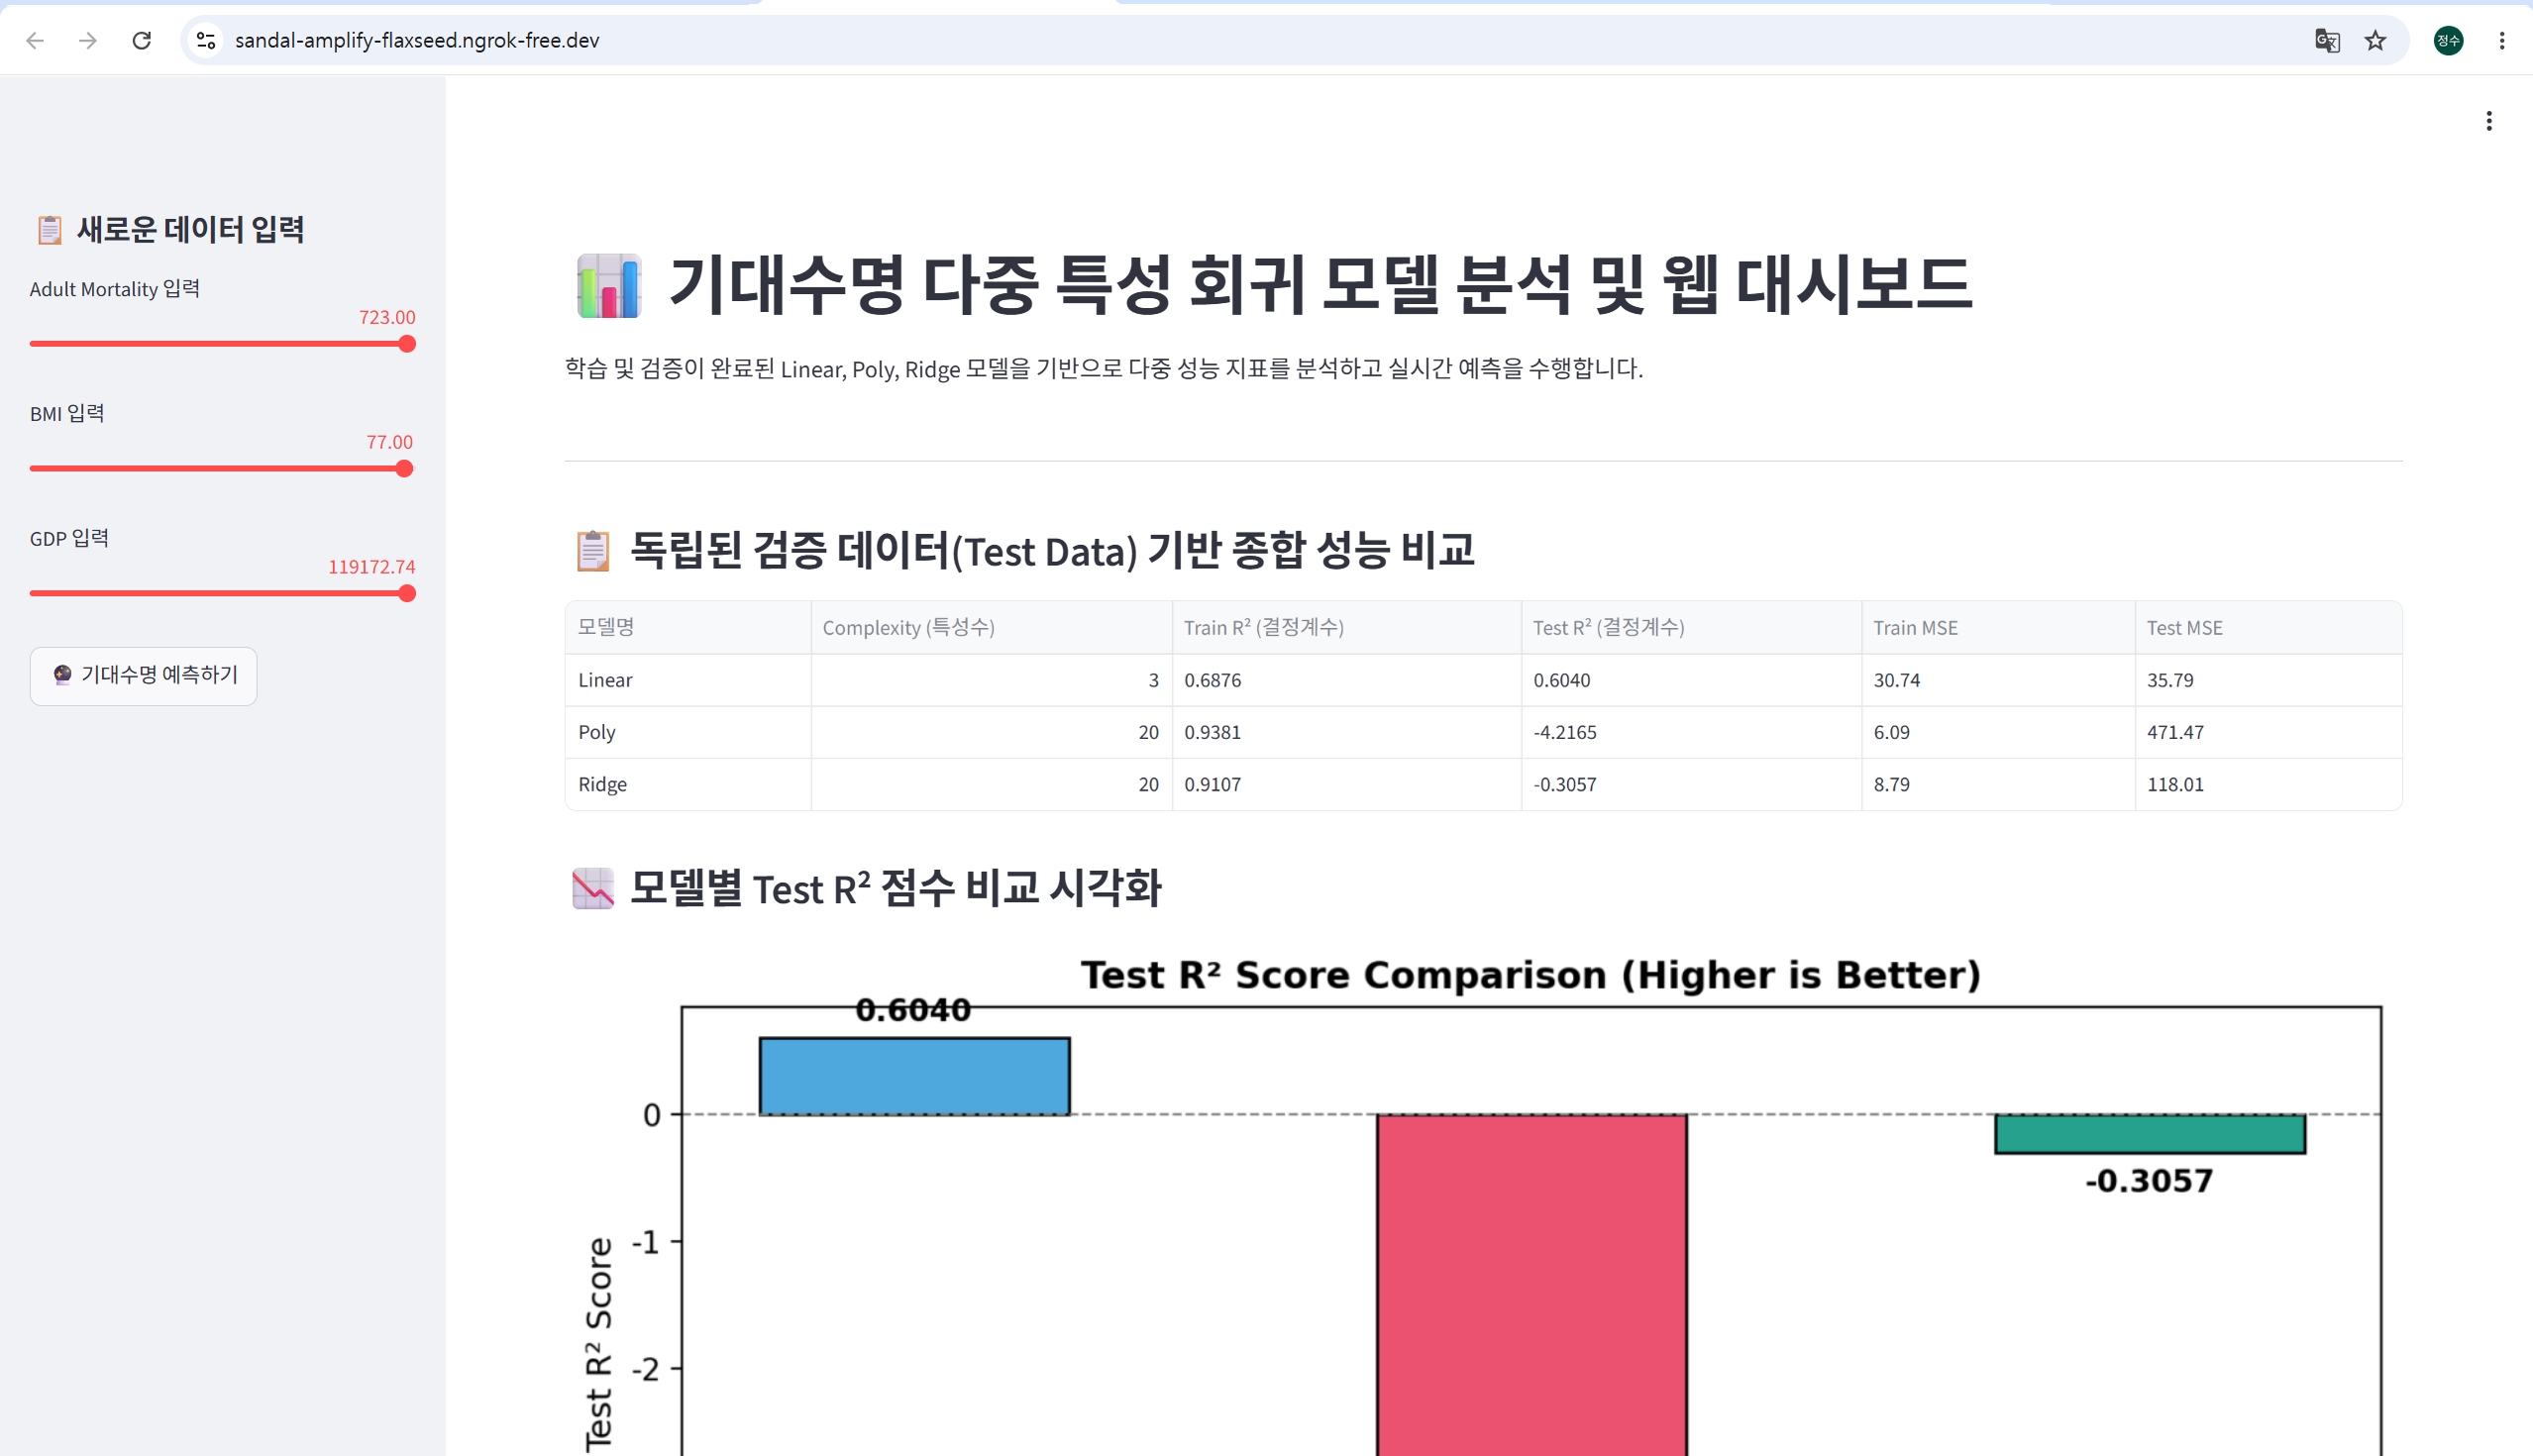

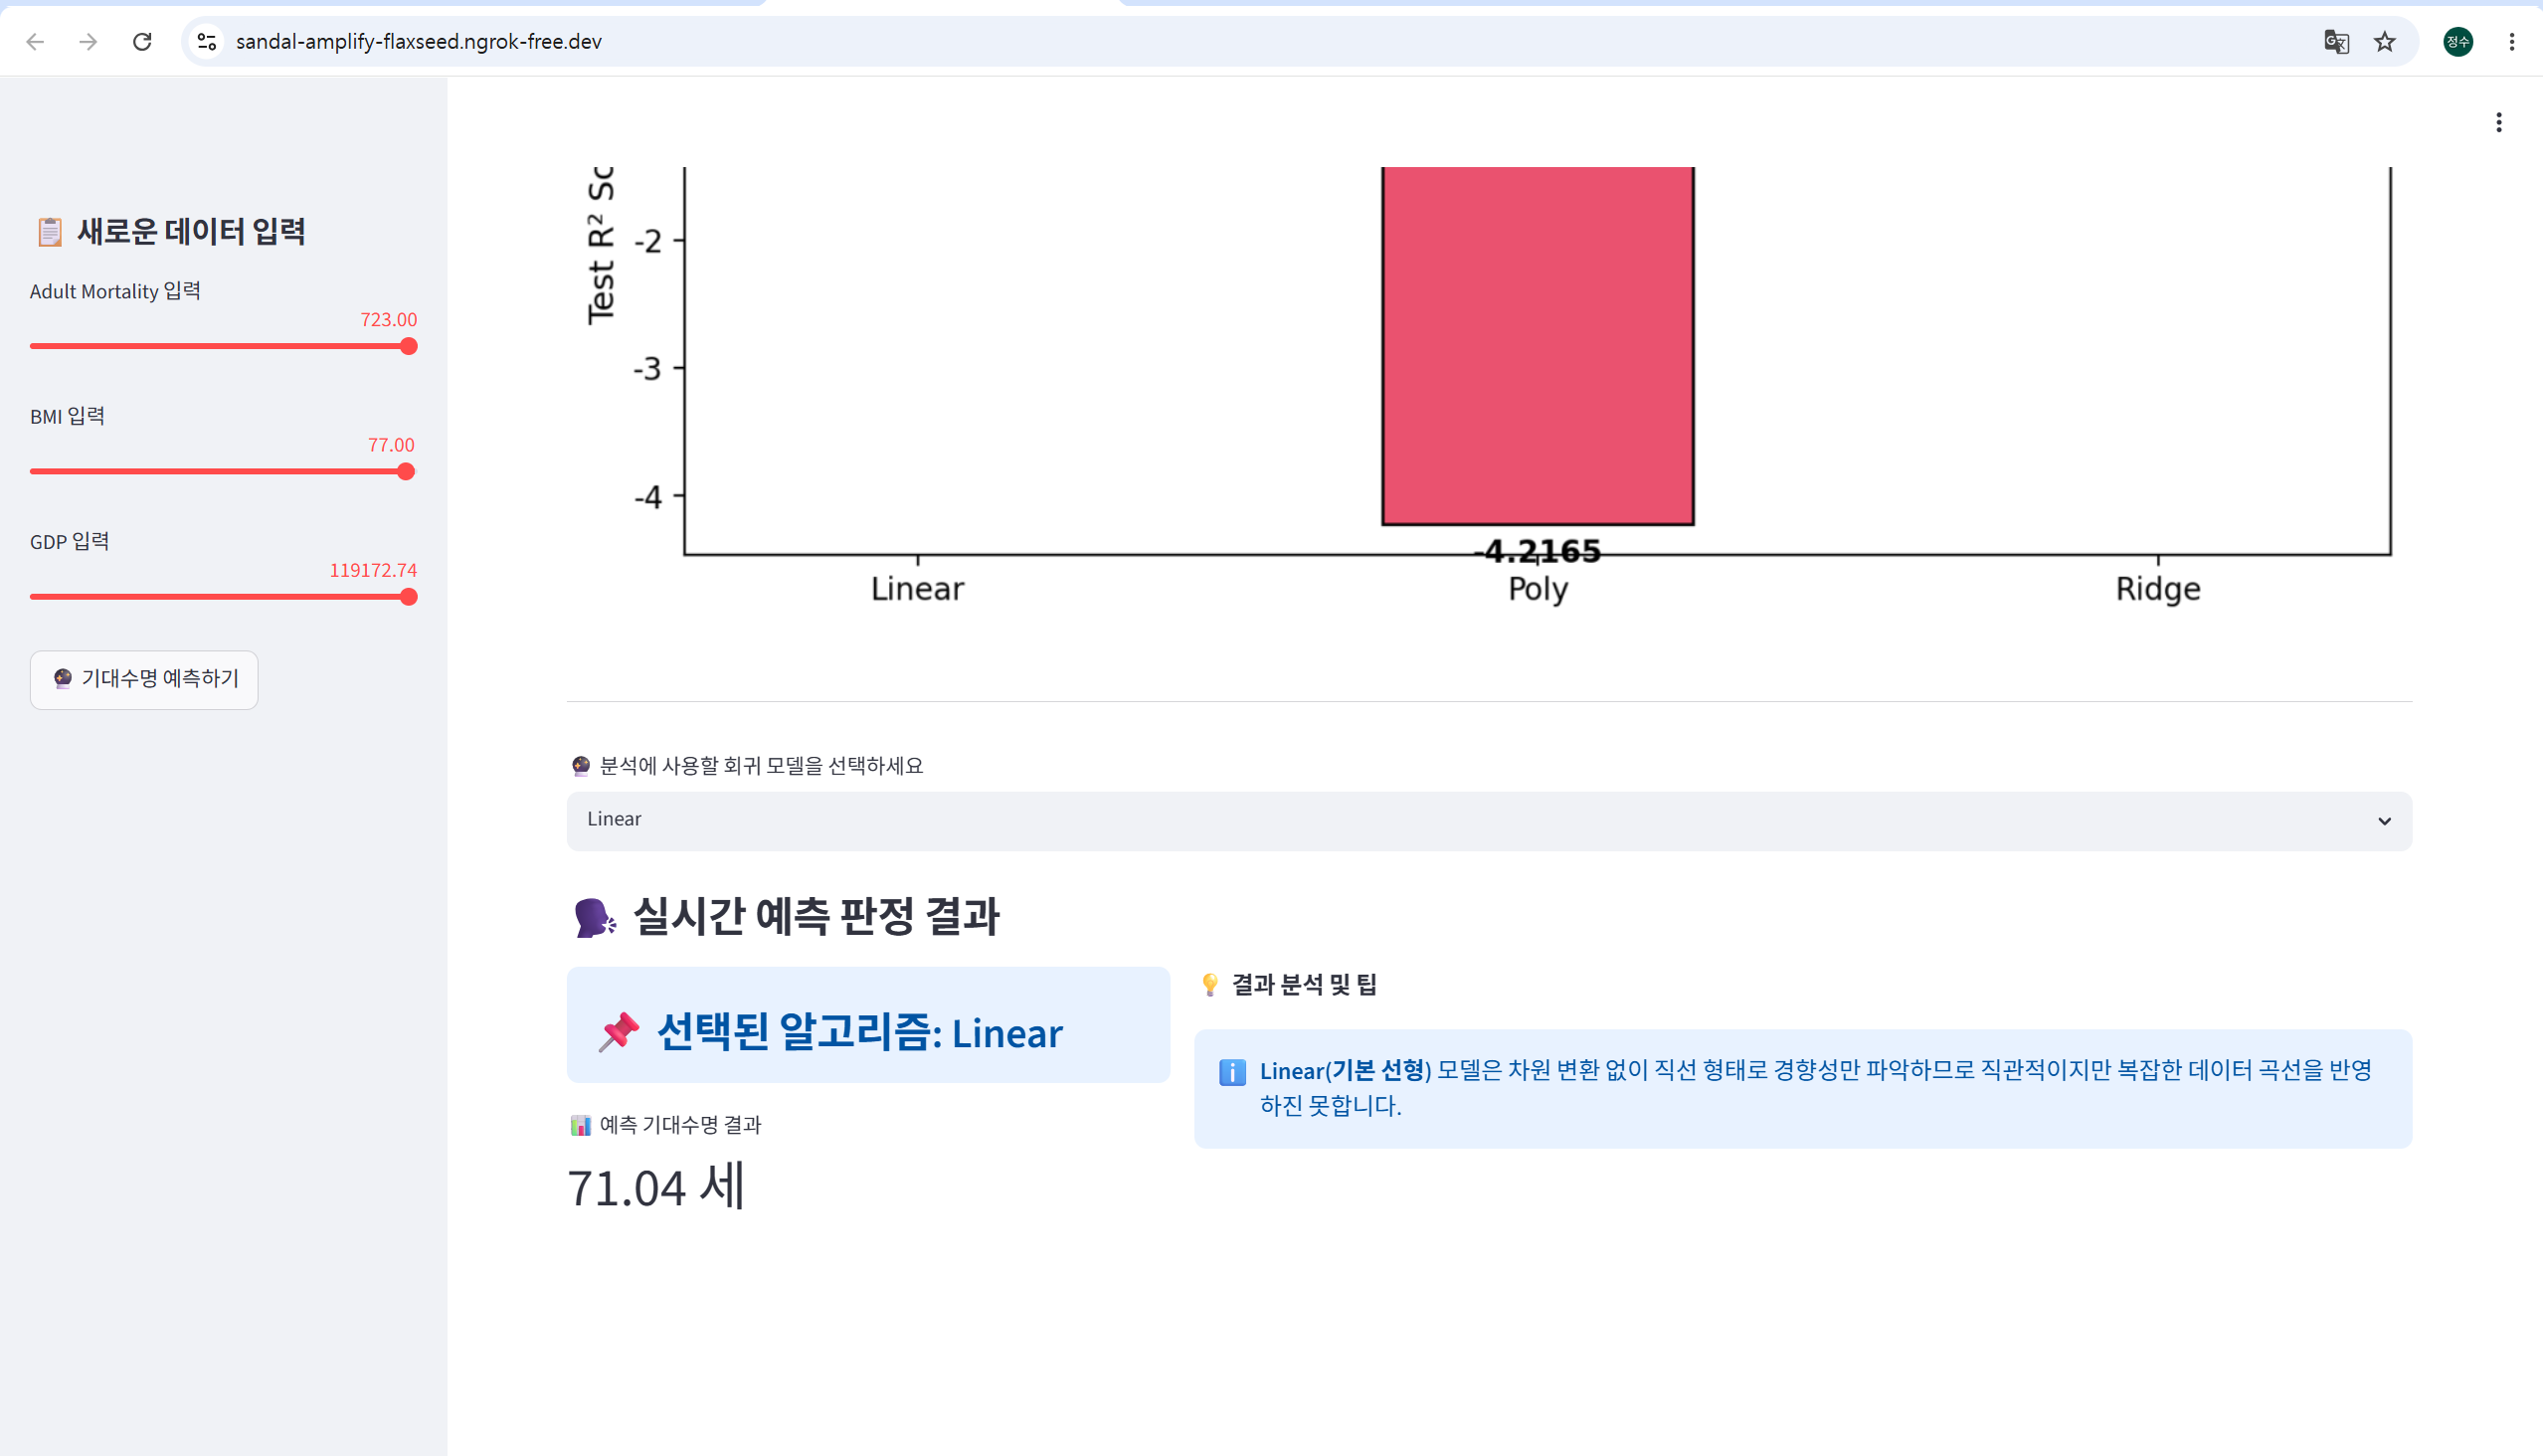